<>:104: SyntaxWarning: invalid escape sequence '\p'
<>:110: SyntaxWarning: invalid escape sequence '\p'
<>:104: SyntaxWarning: invalid escape sequence '\p'
<>:110: SyntaxWarning: invalid escape sequence '\p'
/var/folders/kq/dktrln_x0tgf7tr54wrn711r0000gn/T/ipykernel_25872/1542386840.py:104: SyntaxWarning: invalid escape sequence '\p'
  plt.plot(r_grid, np.degrees(psi_est_profile), color='red', linewidth=3, label='Learned $\psi(r)$')
/var/folders/kq/dktrln_x0tgf7tr54wrn711r0000gn/T/ipykernel_25872/1542386840.py:110: SyntaxWarning: invalid escape sequence '\p'
  plt.title("Learned Spiral Structure (Mod $\pi$)")


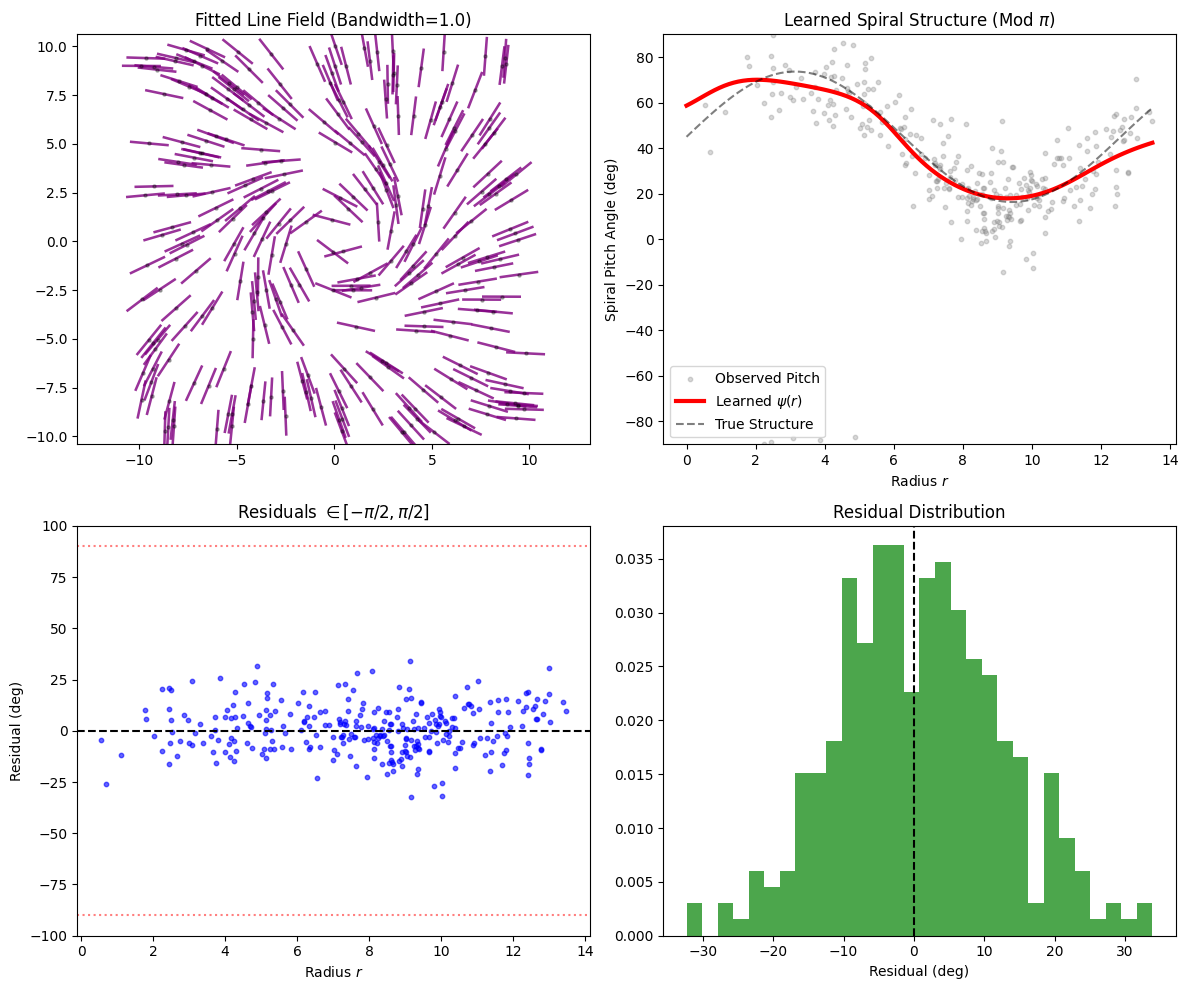

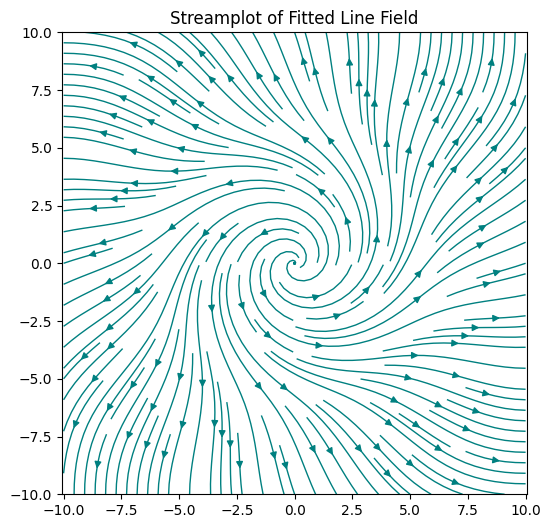

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# --- 1. Synthetic Line Field Data ---
np.random.seed(42)
n_points = 300
X = np.random.uniform(-10, 10, n_points)
Y = np.random.uniform(-10, 10, n_points)
r = np.sqrt(X**2 + Y**2) + 1e-6
phi_spatial = np.arctan2(Y, X)

# Define True "Spiral Pitch" (Angle relative to radius)
# Example: 45 degrees constant (Log Spiral) -> psi = pi/4
# We will make it vary with r to show off the non-parametric capability
psi_true = np.pi/4 + 0.5 * np.sin(r/2)

# Global Angle of the line
theta_true = phi_spatial + psi_true

# Add Noise (Von Mises is theoretically better for angles, but Gaussian is fine for high SNR)
noise = np.random.normal(0, 0.2, n_points) 
theta_obs = theta_true + noise

# Note: We do NOT generate U/V vectors here because signs don't matter.
# We work purely with angles.

# --- 2. The "Double Angle" Kernel Smoothing ---

def gaussian_kernel(u):
    return (1.0 / np.sqrt(2 * np.pi)) * np.exp(-0.5 * u**2)

def smooth_line_field(target_r, sample_r, sample_theta, sample_phi_spatial, bandwidth):
    """
    Performs kernel regression on the relative angle (spiral pitch)
    using the double-angle representation.
    """
    # 1. Compute Relative Angle (Spiral Pitch)
    # This removes the rotational component, leaving just the spiral geometry
    psi_obs = sample_theta - sample_phi_spatial
    
    # 2. Map to 2*psi space (Doubling)
    # This maps [0, pi) to [0, 2pi), removing the ambiguity between direction and -direction
    cos_2psi = np.cos(2 * psi_obs)
    sin_2psi = np.sin(2 * psi_obs)
    
    # 3. Kernel Smoothing on components
    # Calculate weights
    u = (target_r[:, None] - sample_r[None, :]) / bandwidth
    weights = gaussian_kernel(u)
    sum_weights = np.sum(weights, axis=1)
    sum_weights[sum_weights < 1e-10] = 1.0 # Avoid div/0
    
    # Weighted averages
    avg_cos = np.sum(weights * cos_2psi[None, :], axis=1) / sum_weights
    avg_sin = np.sum(weights * sin_2psi[None, :], axis=1) / sum_weights
    
    # 4. Recover Angle
    # atan2 gives angle in (-pi, pi], divide by 2 gives (-pi/2, pi/2]
    psi_est = 0.5 * np.arctan2(avg_sin, avg_cos)
    
    return psi_est

# Define grid and bandwidth
r_grid = np.linspace(0, np.max(r), 100)
bandwidth = 1.0

# Fit the model
psi_est_profile = smooth_line_field(r_grid, r, theta_obs, phi_spatial, bandwidth)

# Predict on training data for residuals
psi_fitted = smooth_line_field(r, r, theta_obs, phi_spatial, bandwidth)
theta_fitted = phi_spatial + psi_fitted

# --- 3. Compute Line Field Residuals ---
# Error must be wrapped to [-pi/2, pi/2]
raw_error = theta_obs - theta_fitted
residuals = np.mod(raw_error + np.pi/2, np.pi) - np.pi/2

# Convert to degrees for easier reading
res_deg = np.degrees(residuals)

# --- 4. Visualization ---

plt.figure(figsize=(12, 10))

# Plot 1: The Vector Field (Headless)
plt.subplot(2, 2, 1)
# Create headless vectors for visualization
U_vis = np.cos(theta_fitted)
V_vis = np.sin(theta_fitted)
# We plot the field with NO heads to emphasize it's a line field
plt.quiver(X, Y, U_vis, V_vis, angles='xy', scale_units='xy', scale=0.5, 
           headwidth=0, headlength=0, headaxislength=0, # No arrows
           pivot='mid', color='purple', alpha=0.8, width=0.005)
plt.scatter(X, Y, s=5, c='k', alpha=0.3)
plt.title(f"Fitted Line Field (Bandwidth={bandwidth})")
plt.axis('equal')

# Plot 2: The Structure Function (Psi vs r)
plt.subplot(2, 2, 2)
# Wrap observed psi for plotting consistency
psi_obs_wrapped = np.arctan(np.tan(theta_obs - phi_spatial)) 
plt.scatter(r, np.degrees(psi_obs_wrapped), alpha=0.3, color='gray', s=10, label='Observed Pitch')
plt.plot(r_grid, np.degrees(psi_est_profile), color='red', linewidth=3, label='Learned $\psi(r)$')
plt.plot(r_grid, np.degrees(np.pi/4 + 0.5 * np.sin(r_grid/2)), 'k--', alpha=0.5, label='True Structure')
plt.xlabel('Radius $r$')
plt.ylabel('Spiral Pitch Angle (deg)')
plt.ylim(-90, 90)
plt.legend()
plt.title("Learned Spiral Structure (Mod $\pi$)")

# Plot 3: Residuals Scatter
plt.subplot(2, 2, 3)
plt.scatter(r, res_deg, alpha=0.6, color='blue', s=10)
plt.axhline(0, color='k', linestyle='--')
plt.axhline(90, color='r', linestyle=':', alpha=0.5)
plt.axhline(-90, color='r', linestyle=':', alpha=0.5)
plt.xlabel('Radius $r$')
plt.ylabel('Residual (deg)')
plt.title(r'Residuals $\in [-\pi/2, \pi/2]$')
plt.ylim(-100, 100)

# Plot 4: Residual Histogram
plt.subplot(2, 2, 4)
plt.hist(res_deg, bins=30, color='green', alpha=0.7, density=True)
plt.axvline(0, color='k', linestyle='--')
plt.xlabel('Residual (deg)')
plt.title('Residual Distribution')

plt.tight_layout()
plt.show()

### Show streamplot of the fitted line field
plt.figure(figsize=(6,6))
Y_grid, X_grid = np.mgrid[-10:10:100j, -10:10:100j]
R_grid = np.sqrt(X_grid**2 + Y_grid**2) + 1e-6
Phi_grid = np.arctan2(Y_grid, X_grid)
Psi_grid = smooth_line_field(R_grid.flatten(), r, theta_obs, phi_spatial, bandwidth).reshape(R_grid.shape)
Theta_grid = Phi_grid + Psi_grid
U_grid = np.cos(Theta_grid)
V_grid = np.sin(Theta_grid)

plt.streamplot(X_grid, Y_grid, U_grid, V_grid, color='teal', density=1.5, linewidth=1)
plt.title('Streamplot of Fitted Line Field')
plt.axis('equal')
plt.show()  


Using Bandwidth h = 29.54


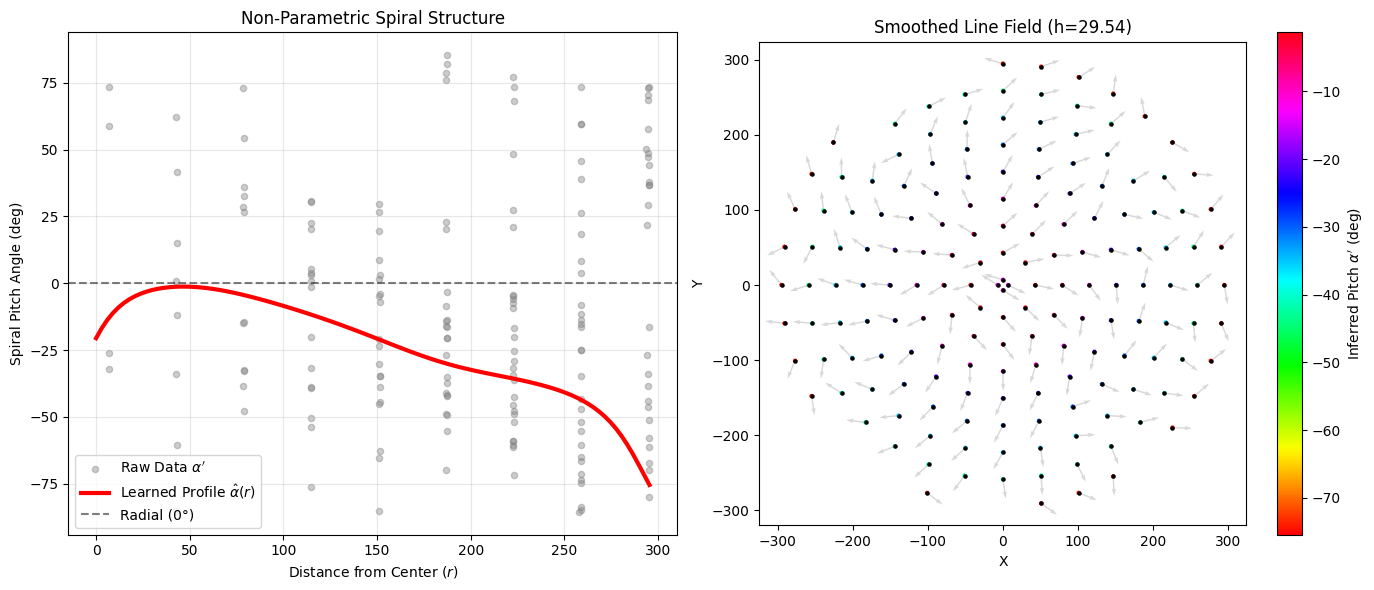

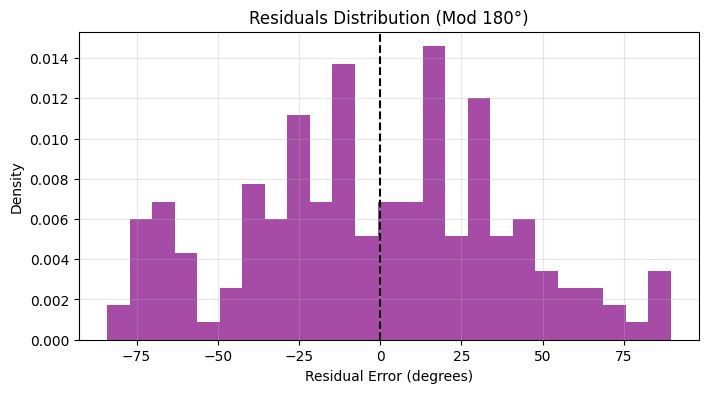

In [51]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import ast

# --- 1. Data Preparation (Using your parsing logic) ---
# We assume 'df' is your loaded dataframe
# If you need dummy data to run this immediately, uncomment the block below:
# ---------------------------------------------------------
# N = 300
# df = pd.DataFrame()
# # Synthetic data: r roughly 0 to 10
# X_syn = np.random.uniform(-10, 10, N)
# Y_syn = np.random.uniform(-10, 10, N)
# r_syn = np.sqrt(X_syn**2 + Y_syn**2)
# # True structure: pitch decays from 45 deg to 0 deg
# alpha_true = 45 * np.exp(-r_syn/5) + np.random.normal(0, 10, N)
# df['Angle (α′)'] = alpha_true
# df['Coordinate'] = [f"({x:.2f}, {y:.2f})" for x, y in zip(X_syn, Y_syn)]
# ---------------------------------------------------------

def parse_coord(s):
    if isinstance(s, (list, tuple, np.ndarray)):
        return list(s)
    if not isinstance(s, str):
        return [np.nan, np.nan]
    s = s.strip()
    try:
        val = ast.literal_eval(s)
        return list(val)
    except Exception:
        parts = [p.strip() for p in s.strip("()[]").split(",")]
        try:
            return [float(parts[0]), float(parts[1])]
        except Exception:
            return [np.nan, np.nan]

coordinates = df['Coordinate'].apply(parse_coord).tolist()
X = np.array([coord[0] for coord in coordinates])
Y = np.array([coord[1] for coord in coordinates])

# Compute Spatial Parameters
r_obs = np.sqrt(X**2 + Y**2)
theta_spatial = np.arctan2(Y, X) # Radians

# Observed Relative Angle (Pitch) in Radians
# We use this directly for smoothing
alpha_obs_deg = df['Angle (α′)'].values
alpha_obs_rad = np.radians(alpha_obs_deg)

# --- 2. The Line-Field Kernel Smoother ---

def gaussian_kernel(u):
    return (1.0 / np.sqrt(2 * np.pi)) * np.exp(-0.5 * u**2)

# def epchanovik_kernel(u):

def smooth_spiral_pitch(target_r, sample_r, sample_alpha_rad, bandwidth):
    """
    Smooths the relative spiral angle alpha using double-angle metric
    to respect line field symmetry (alpha == alpha + pi).
    """
    # Map to double angle space (2*alpha)
    # This maps 90 deg and -90 deg to the same vector in the embedding space
    cos_2alpha = np.cos(2 * sample_alpha_rad)
    sin_2alpha = np.sin(2 * sample_alpha_rad)
    
    # Kernel weights
    u = (target_r[:, None] - sample_r[None, :]) / bandwidth
    weights = gaussian_kernel(u)
    
    sum_weights = np.sum(weights, axis=1)
    # Handle data gaps
    sum_weights[sum_weights < 1e-10] = 1.0 
    
    # Weighted average of components
    avg_cos = np.sum(weights * cos_2alpha[None, :], axis=1) / sum_weights
    avg_sin = np.sum(weights * sin_2alpha[None, :], axis=1) / sum_weights
    
    # Recover angle: atan2 gives (-pi, pi], divide by 2 gives (-pi/2, pi/2]
    alpha_est = 0.5 * np.arctan2(avg_sin, avg_cos)
    
    return alpha_est

# --- 3. Execution ---

# Setup Grid
r_grid = np.linspace(0, np.max(r_obs), 100)

# Tunable Hyperparameter (Bandwidth)
# Since coordinates look like they range 0-10 or 0-100, pick reasonable scale
# If X is ~2000 units, b should be ~200. If X is ~10 units, b ~ 1.0.
bandwidth = np.percentile(r_obs, 99) / 10.0 
print(f"Using Bandwidth h = {bandwidth:.2f}")

# 1. Learn the Structure Function alpha(r)
alpha_fitted_rad_grid = smooth_spiral_pitch(r_grid, r_obs, alpha_obs_rad, bandwidth)

# 2. Predict on original points (for residuals/plotting)
alpha_fitted_rad = smooth_spiral_pitch(r_obs, r_obs, alpha_obs_rad, bandwidth)

# 3. Reconstruct Global Field vectors
# phi_fitted = theta_spatial + alpha_fitted(r)
phi_fitted_rad = theta_spatial + alpha_fitted_rad
U_fit = np.cos(phi_fitted_rad)
V_fit = np.sin(phi_fitted_rad)

# --- 4. Visualization ---

plt.figure(figsize=(14, 6))

# Subplot 1: The Structure Function (The Physics)
# This shows exactly how the spiral pitch changes with distance
plt.subplot(1, 2, 1)
# Wrap observed alphas to [-90, 90] for consistent plotting
alpha_obs_wrapped = np.degrees(np.arctan(np.tan(alpha_obs_rad)))
plt.scatter(r_obs, alpha_obs_wrapped, c='gray', alpha=0.4, s=20, label='Raw Data $\\alpha\'$')
plt.plot(r_grid, np.degrees(alpha_fitted_rad_grid), color='red', linewidth=3, label='Learned Profile $\\hat{\\alpha}(r)$')
plt.axhline(0, color='k', linestyle='--', alpha=0.5, label='Radial (0°)')
plt.xlabel('Distance from Center ($r$)')
plt.ylabel('Spiral Pitch Angle (deg)')
plt.title('Non-Parametric Spiral Structure')
plt.legend()
plt.grid(alpha=0.3)

# Subplot 2: The Vector Field Comparison
ax2 = plt.subplot(1, 2, 2)

# Plot Original Noisy Field (Gray/Thin)
phi_obs_rad = np.radians(df['Angle (α′)'].values) + theta_spatial
U_raw = np.cos(phi_obs_rad)
V_raw = np.sin(phi_obs_rad)
plt.quiver(X, Y, U_raw, V_raw, color='gray', alpha=0.3, 
           scale=25, width=0.003, headwidth=3)

# Plot Fitted Smooth Field (Colored/Thick)
# Using headwidth=0 to denote Line Field (Director field)
q = plt.quiver(X, Y, U_fit, V_fit, np.degrees(alpha_fitted_rad),
           angles='xy', scale_units='xy', scale=1, cmap='hsv',
           width=0.01, headwidth=0, pivot='mid') # Headless vectors

plt.colorbar(q, label='Inferred Pitch $\\alpha\'$ (deg)')
plt.scatter(X, Y, c='k', s=5, zorder=3)
ax2.set_aspect('equal')
plt.xlabel('X')
plt.ylabel('Y')
plt.title(f'Smoothed Line Field (h={bandwidth:.2f})')

plt.tight_layout()
plt.show()

# --- 5. Residual Analysis (Mod Pi) ---
# Calculate error in [-pi/2, pi/2]
error_rad = alpha_obs_rad - alpha_fitted_rad
residuals = np.mod(error_rad + np.pi/2, np.pi) - np.pi/2
residuals_deg = np.degrees(residuals)

plt.figure(figsize=(8, 4))
plt.hist(residuals_deg, bins=25, color='purple', alpha=0.7, density=True)
plt.axvline(0, color='k', linestyle='--')
plt.xlabel('Residual Error (degrees)')
plt.ylabel('Density')
plt.title('Residuals Distribution (Mod 180°)')
plt.grid(alpha=0.3)
plt.show()

  Ring     Coordinate  Angle (α′)        Pattern
0    1   (7.00, 0.00)      -26.09      Clockwise
1    1  (0.00, -7.00)       58.86  Anticlockwise
2    1  (-7.00, 0.00)      -31.99      Clockwise
3    1   (0.00, 7.00)       73.30  Anticlockwise
4    2  (43.00, 0.00)      -11.86      Clockwise


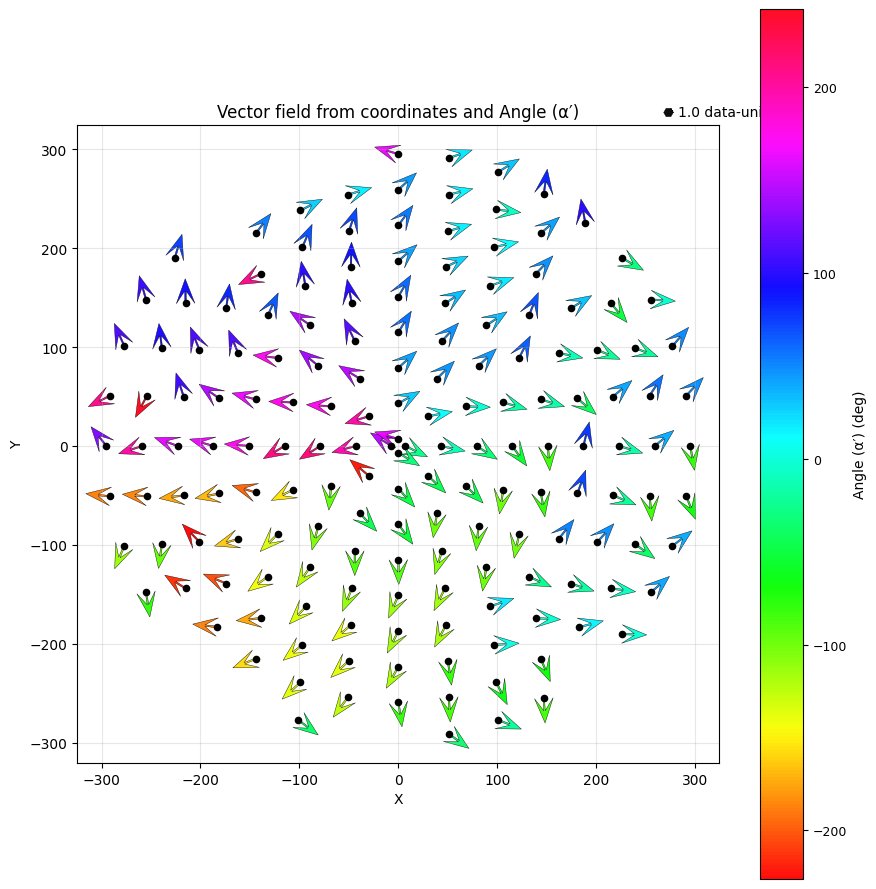

In [31]:
import pandas as pd
from pathlib import Path
file_name = 'Front_EE-1_1_3000x_rings_coords.csv'
path_to_main_folder = Path('/Users/rishabhkumar/spiral-chirals')
# csv_file = Path('/Users/rishabhkumar/spiral-chirals/vf_exports/Front_EE-1_1_3000x_rings_coords.csv')
csv_file = path_to_main_folder / 'vf_exports' / file_name
with open(csv_file, 'r') as f:
    df = pd.read_csv(f)

print(df.head())
# remove the last row 
df = df.iloc[:-1]
import matplotlib.pyplot as plt
import numpy as np
# helper functions 
import ast

def parse_coord(s):
    if isinstance(s, (list, tuple, np.ndarray)):
        return list(s)
    if not isinstance(s, str):
        return [np.nan, np.nan]
    s = s.strip()
    try:
        val = ast.literal_eval(s)          # handles "(7.00, 0.00)" or "[7.00, 0.00]"
        return list(val)
    except Exception:
        parts = [p.strip() for p in s.strip("()[]").split(",")]
        try:
            return [float(parts[0]), float(parts[1])]
        except Exception:
            return [np.nan, np.nan]
# Extract angles and filter valid data
angles_deg = df['Angle (α′)'].values 

# df['Coordinate'] = df['Coordinate'].apply(lambda x: np.array(x))    
coordinates = df['Coordinate'].apply(parse_coord).tolist()
# Find global theta from the coordinates 

# For these angles and coordinates, plot a vector field
X = [coord[0] for coord in coordinates]
Y = [coord[1] for coord in coordinates]
r = np.sqrt(np.array(X)**2 + np.array(Y)**2)
theta = np.arctan2(
    np.array(Y),
    np.array(X)
)
phi = angles_deg + np.degrees(theta)
phi_rad = np.deg2rad(phi)
U_plot = np.cos(phi_rad)
V_plot = np.sin(phi_rad)
# Compute a reasonable scale factor for the quiver key
scale_factor = np.round(np.percentile(np.sqrt(U_plot**2 + V_plot**2), 75), 1)
if scale_factor == 0:
    scale_factor = 1.0
# Create the plot
plt.figure(figsize=(9, 9))
magnitude_scale = 25.0
U_plot_scaled = magnitude_scale * U_plot
V_plot_scaled = magnitude_scale * V_plot
q = plt.quiver(
    X, Y, U_plot_scaled, V_plot_scaled, phi,
    angles='xy', scale_units='xy', scale=1, cmap='hsv',
    width=0.015,
    headwidth=12,
    headlength=16,
    headaxislength=8,
    alpha=0.95, edgecolor='k', linewidth=0.3
)
plt.scatter(X, Y, c='k', s=20, zorder=3)
plt.gca().set_aspect('equal', 'box')
plt.xlabel('X')
plt.ylabel('Y')
plt.title(f'Vector field from coordinates and Angle (α′)')
cbar = plt.colorbar(q, label='Angle (α′) (deg)')
cbar.ax.tick_params(labelsize=9)
plt.quiverkey(q, X=0.92, Y=1.02, U=scale_factor,
              label=f'{scale_factor} data-units', labelpos='E',
              fontproperties={'size':10})
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('vector_field_plot.svg', dpi=300)
plt.show()


/Users/rishabhkumar/miniconda3/lib/python3.12/site-packages/matplotlib/patches.py:3421: RuntimeWarning: invalid value encountered in scalar divide
  cos_t, sin_t = head_length / head_dist, head_width / head_dist


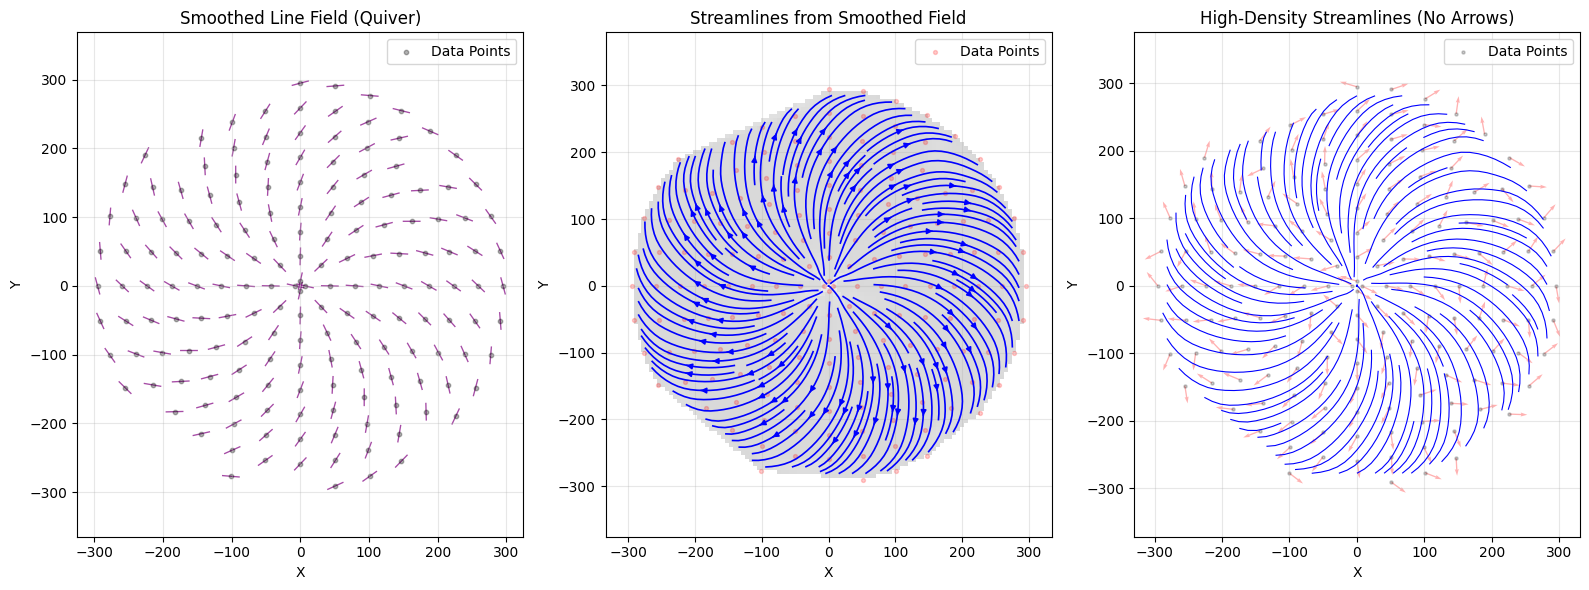

Grid shape: (100, 100)
Data range: X=[-295.00, 295.00], Y=[-291.00, 295.00]


In [ ]:
# --- Streamline Visualization from Smoothed Line Field Data ---
from scipy.interpolate import griddata

# Create a regular grid for streamplot
# Use the extent of the actual data
X = np.array(X)
Y = np.array(Y)
xi_smooth = np.linspace(X.min(), X.max(), 100)
yi_smooth = np.linspace(Y.min(), Y.max(), 100)
Xi_smooth, Yi_smooth = np.meshgrid(xi_smooth, yi_smooth)

# Interpolate the smoothed U_fit and V_fit onto the regular grid
# This is necessary because streamplot requires data on a regular meshgrid
Ui_smooth = griddata((X, Y), U_fit, (Xi_smooth, Yi_smooth), method='linear')
Vi_smooth = griddata((X, Y), V_fit, (Xi_smooth, Yi_smooth), method='linear')

# Visualization
plt.figure(figsize=(16, 6))

# Plot 1: Original Smoothed Line Field (Quiver)
plt.subplot(1, 3, 1)
plt.title("Smoothed Line Field (Quiver)", fontsize=12)
plt.quiver(X, Y, U_fit, V_fit, 
           pivot='mid', 
           headwidth=0, headlength=0, headaxislength=0,  # Headless for line field
           scale=25, width=0.003, color='purple', alpha=0.7)
plt.scatter(X, Y, color='black', s=10, alpha=0.3, label='Data Points')
plt.axis('equal')
plt.xlabel('X')
plt.ylabel('Y')
plt.legend()
plt.grid(alpha=0.3)

# Plot 2: Streamlines from Smoothed Field
plt.subplot(1, 3, 2)
plt.title("Streamlines from Smoothed Field", fontsize=12)

# Background showing magnitude
magnitude_smooth = np.sqrt(Ui_smooth**2 + Vi_smooth**2)
plt.pcolormesh(Xi_smooth, Yi_smooth, magnitude_smooth, 
               cmap='Greys', alpha=0.15, shading='auto')

# Streamplot with moderate density
plt.streamplot(Xi_smooth, Yi_smooth, Ui_smooth, Vi_smooth,
               density=2.0,  # Controls line spacing
               color='blue',
               linewidth=1.2,
               arrowsize=0.8)  # Small arrows to show direction

plt.scatter(X, Y, color='red', s=8, alpha=0.2, label='Data Points')
plt.axis('equal')
plt.xlabel('X')
plt.ylabel('Y')
plt.legend()
plt.grid(alpha=0.3)

# Plot 3: High-Density Streamlines (Line Field Style)
plt.subplot(1, 3, 3)
plt.title("Streamlines overlayed on real-data", fontsize=12)
plt.quiver(X, Y, U_raw, V_raw, color='red', alpha=0.3, 
           scale=25, width=0.003, headwidth=3)
plt.streamplot(Xi_smooth, Yi_smooth, Ui_smooth, Vi_smooth,
               density=1.5,  # More lines
               color='blue',
               linewidth=0.8,
               arrowsize=0)  # No arrows = pure line field

plt.scatter(X, Y, color='black', s=5, alpha=0.2, label='Data Points')
plt.axis('equal')
plt.xlabel('X')
plt.ylabel('Y')
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Grid shape: {Xi_smooth.shape}")
print(f"Data range: X=[{X.min():.2f}, {X.max():.2f}], Y=[{Y.min():.2f}, {Y.max():.2f}]")

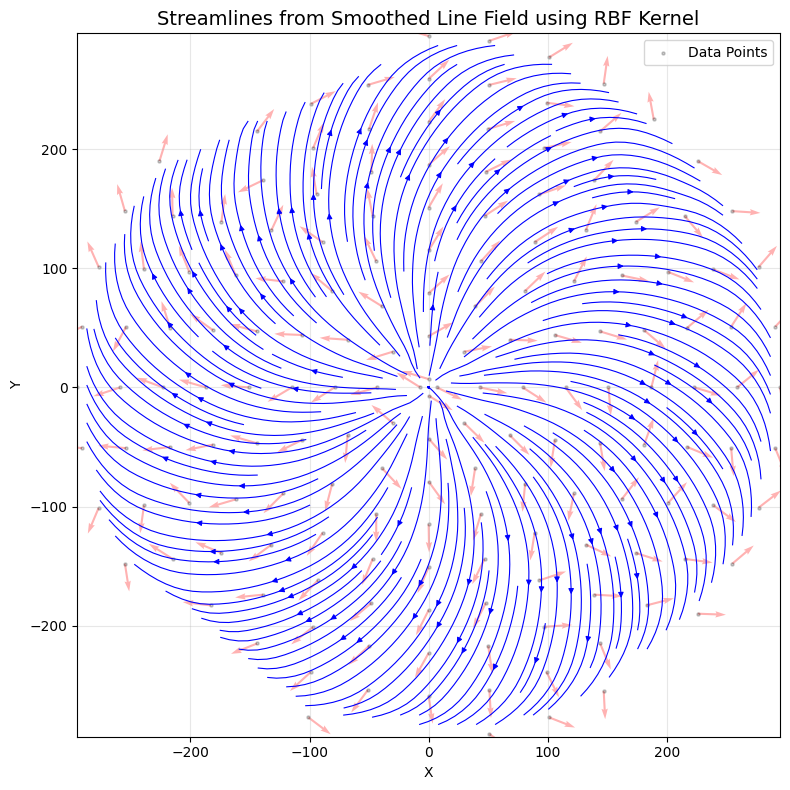

In [49]:
# Save figure for smoothed line field streamlines
plt.figure(figsize=(8, 8))
plt.title("Streamlines from Smoothed Line Field using RBF Kernel", fontsize=14)
plt.quiver(X, Y, U_raw, V_raw, color='red', alpha=0.3, 
           scale=25, width=0.003, headwidth=3)
plt.streamplot(Xi_smooth, Yi_smooth, Ui_smooth, Vi_smooth,
               density=2.5,  # Some lines
               color='blue',
               linewidth=0.8,
               arrowsize=0.8)  # No arrows = pure line field
plt.scatter(X, Y, color='black', s=5, alpha=0.2, label='Data Points')
plt.xlabel('X')
plt.ylabel('Y')
plt.axis('equal')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('smoothed_line_field_streamlines_RBF_kernel.svg', dpi=300)
plt.show()

In [62]:
import numpy as np
import pandas as pd
from scipy import stats

class SpiralBayes:
    def __init__(self, coordinates, angles_deg=None, vectors=None):
        """
        Input:
        coordinates: list or array of (x, y)
        vectors: list or array of (u, v) observed vectors
        """
        self.coords = np.array(coordinates)
        self.vectors = np.array(vectors)
        self.n = len(self.coords)
        self.n_obs = 2 * self.n  # x and y components count separately
        
        # Precompute polar coords
        self.x = self.coords[:, 0]
        self.y = self.coords[:, 1]
        self.r = np.sqrt(self.x**2 + self.y**2)
        self.phi = np.arctan2(self.y, self.x)
        
        # Stack Observations Y = [u1, v1, u2, v2, ...]
        self.Y = self.vectors.flatten() # Flattens to [u1, v1, u2, v2...] if shape is (n,2)
        
    def fit_model(self, p):
        """
        Fits the linear model for a specific p using OLS.
        Returns: params (A, b), RSS, BIC
        """
        # Construct Design Matrix X_p
        # Col 0: Coeff of A (Radial term)
        # Col 1: Coeff of b (Tangential term)
        
        # Radial basis function g'(r) = r^(p-1)
        # Note: avoid division by zero if r includes 0
        r_safe = self.r.copy()
        r_safe[r_safe < 1e-6] = 1e-6
        
        gp = r_safe**(-1 - p)
        
        # Build X matrix (2n x 2)
        X = np.zeros((self.n_obs, 2))
        
        # Fill X components
        # For U (x-components), even indices
        X[0::2, 0] = gp * np.cos(self.phi)      # A term
        X[0::2, 1] = (1/r_safe) * np.sin(self.phi) # b term
        
        # For V (y-components), odd indices
        X[1::2, 0] = gp * np.sin(self.phi)      # A term
        X[1::2, 1] = -(1/r_safe) * np.cos(self.phi) # b term
        
        # Solve OLS: (X'X)^-1 X'Y
        # Using lstsq for numerical stability
        theta, residuals, rank, s = np.linalg.lstsq(X, self.Y, rcond=None)
        
        A, b = theta
        RSS = residuals[0] if len(residuals) > 0 else np.sum((self.Y - X @ theta)**2)
        
        # Calculate BIC
        # k = 2 parameters (A, b)
        k = 2
        ll = -0.5 * self.n_obs * np.log(RSS / self.n_obs) # Log Likelihood constant omitted (cancels in diff)
        bic = self.n_obs * np.log(RSS / self.n_obs) + k * np.log(self.n_obs)
        
        return {'p': p, 'A': A, 'b': b, 'RSS': RSS, 'BIC': bic}

    def compare_spirals(self):
        models = {
            'Logarithmic': 0,
            'Archimedean': 1,
            'Fermat': 2
        }
        
        results = []
        for name, p in models.items():
            res = self.fit_model(p)
            res['Model'] = name
            results.append(res)
            
        df_res = pd.DataFrame(results)
        
        # Calculate Bayes Factors relative to best model
        min_bic = df_res['BIC'].min()
        df_res['Delta_BIC'] = df_res['BIC'] - min_bic
        df_res['BayesFactor'] = np.exp(-0.5 * df_res['Delta_BIC'])
        
        # Interpret BF
        # BF=1 means best model. 
        # BF < 0.01 implies very strong evidence AGAINST that model compared to the best.
        print(df_res)
        return df_res.sort_values('BIC')

# --- Usage Example with your Data ---

# Assuming 'df' is available from your previous code
# We need to construct the observed vectors W from your angles if not already available
# Or if you have U_plot, V_plot from previous step:

# 1. Reconstruct Vectors from your previous U_plot/V_plot
# (Assuming U_plot/V_plot are the unit vectors scaled by magnitude, or just direction)
# If you only have directions, magnitude info is lost, which affects regression.
# Ideally, you use the raw observed vectors W_i. 
# If you only have angles, we assume unit magnitude or known magnitude rho(r).

# Example Dummy Data Loading:
X_vals = np.array([coord[0] for coord in coordinates])
Y_vals = np.array([coord[1] for coord in coordinates])
U_vals = U_plot # From your previous code
V_vals = V_plot # From your previous code

obs_vectors = np.column_stack((U_vals, V_vals))
obs_coords = np.column_stack((X_vals, Y_vals))

# Run Analysis
analysis = SpiralBayes(obs_coords, vectors=obs_vectors)
results = analysis.compare_spirals()

print(results[['Model', 'p', 'A', 'b', 'RSS', 'BayesFactor']])

   p           A         b         RSS         BIC        Model  Delta_BIC  \
0  0   12.479079  0.394933  153.652742 -251.257562  Logarithmic   0.000000   
1  1   35.775603  0.394933  165.849680 -225.591630  Archimedean  25.665932   
2  2  221.955003  0.394933  166.310628 -224.659078       Fermat  26.598484   

   BayesFactor  
0     1.000000  
1     0.000003  
2     0.000002  
         Model  p           A         b         RSS  BayesFactor
0  Logarithmic  0   12.479079  0.394933  153.652742     1.000000
1  Archimedean  1   35.775603  0.394933  165.849680     0.000003
2       Fermat  2  221.955003  0.394933  166.310628     0.000002


In [64]:
import numpy as np
import pandas as pd
from scipy.optimize import minimize

def kernel_matrix(r, bandwidth, sigma_n=1e-2):
    """Computes the RBF Kernel Matrix."""
    dist_sq = (r[:, None] - r[None, :])**2
    K = np.exp(-0.5 * dist_sq / bandwidth**2)
    return K + (sigma_n**2) * np.eye(len(r))

def calculate_gp_lml(r, y, bandwidth, sigma_n):
    """
    Computes the Log Marginal Likelihood for a GP (RKHS) model.
    LML = -0.5 * y.T * K_inv * y - 0.5 * log|K| - n/2 * log(2pi)
    """
    n = len(y)
    K = kernel_matrix(r, bandwidth, sigma_n)
    
    try:
        # Cholesky decomposition for numerical stability
        L = np.linalg.cholesky(K)
        alpha = np.linalg.solve(L.T, np.linalg.solve(L, y))
        
        # Data Fit Term
        data_fit = -0.5 * y.T @ alpha
        # Complexity Penalty Term (log determinant)
        complexity = -np.sum(np.log(np.diag(L)))
        # Constant
        constant = - (n/2) * np.log(2 * np.pi)
        
        return data_fit + complexity + constant
    except np.linalg.LinAlgError:
        return -np.inf

# --- 1. Parametric Comparison Logic ---

def parametric_log_evidence(rss, n, k=2):
    """Approximates Log Evidence using BIC: ln(E) \approx -0.5 * BIC"""
    bic = n * np.log(rss / n) + k * np.log(n)
    return -0.5 * bic

# --- 2. Comprehensive Comparison Execution ---

def perform_bayesian_comparison(analysis_obj, y_r_obs, y_phi_obs, bandwidth=1.0, sigma_n=0.1):
    """
    analysis_obj: The SpiralBayes object containing data
    """
    # Results storage
    comparison = []
    
    # A. Parametric Models (p = 0, 1, 2)
    for name, p_val in {'Log': 0, 'Archimedean': 1, 'Fermat': 2}.items():
        res = analysis_obj.fit_model(p_val)
        ln_E = parametric_log_evidence(res['RSS'], analysis_obj.n_obs)
        comparison.append({'Model': name, 'Type': 'Parametric', 'LogEvidence': ln_E})

    # B. RKHS (Gaussian Process) Model
    # We treat Radial and Tangential components as independent GPs
    lml_r = calculate_gp_lml(analysis_obj.r, y_r_obs, bandwidth, sigma_n)
    lml_phi = calculate_gp_lml(analysis_obj.r, y_phi_obs, bandwidth, sigma_n)
    
    lml_total = lml_r + lml_phi
    comparison.append({'Model': 'RKHS (RBF)', 'Type': 'Non-Parametric', 'LogEvidence': lml_total})

    # --- 3. Compute Bayes Factors ---
    df_comp = pd.DataFrame(comparison)
    max_lml = df_comp['LogEvidence'].max()
    
    # BF relative to the best model
    df_comp['BayesFactor'] = np.exp(df_comp['LogEvidence'] - max_lml)
    
    return df_comp.sort_values('LogEvidence', ascending=False)

# Example call (assuming analysis, Y_r_obs, Y_phi_obs are defined):
results_table = perform_bayesian_comparison(analysis, r, phi)
print(results_table)

         Model            Type   LogEvidence  BayesFactor
0          Log      Parametric  1.256288e+02     1.000000
1  Archimedean      Parametric  1.127958e+02     0.000003
2       Fermat      Parametric  1.123295e+02     0.000002
3   RKHS (RBF)  Non-Parametric -9.209798e+07     0.000000


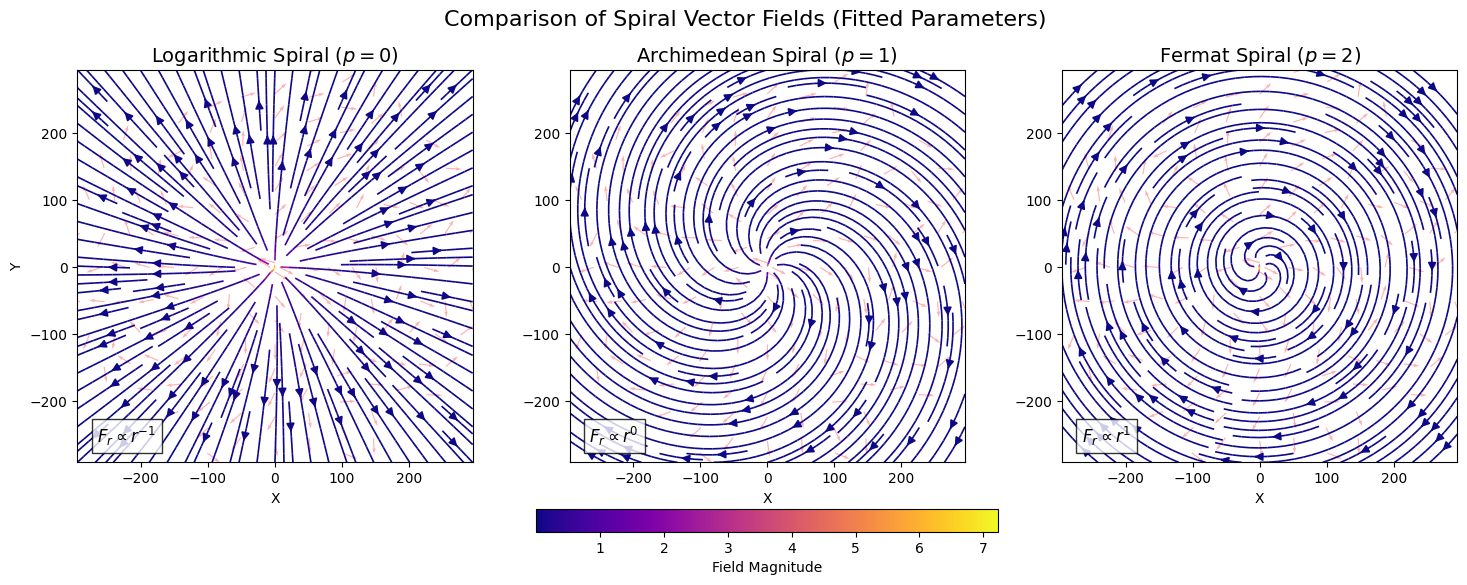

In [56]:
import numpy as np
import matplotlib.pyplot as plt

def get_vector_field(X, Y, p, A=1.0, b=2.0):
    """
    Computes U, V for the general spiral field:
    F = (A * r^(p-1)) e_r - (b / r) e_phi
    """
    r = np.sqrt(X**2 + Y**2) + 1e-6 # Avoid singularity
    
    # Polar basis conversion factors
    cos_phi = X / r
    sin_phi = Y / r
    
    # 1. Physical Components (Polar)
    # Radial component decays as r^(p-1)
    F_r = A * (r**(-p-1))
    
    # Tangential component is always -b/r (Vortex)
    F_phi = -b / r
    
    # 2. Convert to Cartesian (U, V)
    # U = F_r * cos - F_phi * sin
    U = F_r * cos_phi - F_phi * sin_phi
    # V = F_r * sin + F_phi * cos
    V = F_r * sin_phi + F_phi * cos_phi
    
    return U, V

# --- Setup Grid ---
xi_smooth = np.linspace(X.min(), X.max(), 100)
yi_smooth = np.linspace(Y.min(), Y.max(), 100)
Xi_smooth, Yi_smooth = np.meshgrid(xi_smooth, yi_smooth)

# Interpolate the smoothed U_fit and V_fit onto the regular grid
# This is necessary because streamplot requires data on a regular meshgrid
Ui_smooth = griddata((X, Y), U_fit, (Xi_smooth, Yi_smooth), method='linear')
Vi_smooth = griddata((X, Y), V_fit, (Xi_smooth, Yi_smooth), method='linear')

# Constants (tunable to change tightness)
A_val = 1.0  # Radial strength
b_val = 3.0  # Rotational strength

# --- Generate Fields ---
# p=0: Logarithmic
A_log, b_log = results['A'][0], results['b'][0]
U_log, V_log = get_vector_field(Xi_smooth, Yi_smooth, p=0, A=A_log, b=b_log)

# p=1: Archimedean
A_arch, b_arch = results['A'][1], results['b'][1]
U_arch, V_arch = get_vector_field(Xi_smooth, Yi_smooth, p=1, A=A_arch, b=b_arch)
# p=2: Fermat
A_fermat, b_fermat = results['A'][2], results['b'][2]
U_fermat, V_fermat = get_vector_field(Xi_smooth, Yi_smooth, p=2, A=A_fermat, b=b_fermat)

# --- Plotting ---
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
titles = ["Logarithmic Spiral ($p=0$)", "Archimedean Spiral ($p=1$)", "Fermat Spiral ($p=2$)"]
params = [0, 1, 2]
fields = [(U_log, V_log), (U_arch, V_arch), (U_fermat, V_fermat)]

for ax, title, (U, V), p_val in zip(axes, titles, fields, params):
    # Calculate magnitude for color
    speed = np.sqrt(U**2 + V**2)
    # Plot the data points
    
    # Streamplot
    strm = ax.streamplot(Xi_smooth, Yi_smooth, U, V, color=speed, cmap='plasma', 
                         density=1.5, linewidth=1.2, arrowsize=1.2)
    ax.quiver(X, Y, U_raw, V_raw, color='red', alpha=0.3, 
           scale=25, width=0.003, headwidth=3)
    ax.set_title(title, fontsize=14)
    ax.set_aspect('equal')
    ax.set_xlabel('X')
    if ax == axes[0]:
        ax.set_ylabel('Y')
        
    # Annotate the Decay Physics
    decay_text = f"$F_r \\propto r^{{{p_val-1}}}$"
    ax.text(0.05, 0.05, decay_text, transform=ax.transAxes, 
            fontsize=12, bbox=dict(facecolor='white', alpha=0.8))

cbar = fig.colorbar(strm.lines, ax=axes.ravel().tolist(), orientation='horizontal', 
                    fraction=0.05, pad=0.1)
cbar.set_label('Field Magnitude')

plt.suptitle(f"Comparison of Spiral Vector Fields (Fitted Parameters)", fontsize=16)
plt.savefig('spiral_comparison_streamlines.svg', dpi=300)
plt.show()

array([[-295.        , -289.04040404, -283.08080808, ...,  283.08080808,
         289.04040404,  295.        ],
       [-295.        , -289.04040404, -283.08080808, ...,  283.08080808,
         289.04040404,  295.        ],
       [-295.        , -289.04040404, -283.08080808, ...,  283.08080808,
         289.04040404,  295.        ],
       ...,
       [-295.        , -289.04040404, -283.08080808, ...,  283.08080808,
         289.04040404,  295.        ],
       [-295.        , -289.04040404, -283.08080808, ...,  283.08080808,
         289.04040404,  295.        ],
       [-295.        , -289.04040404, -283.08080808, ...,  283.08080808,
         289.04040404,  295.        ]])

In [68]:
import numpy as np
import pandas as pd
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, WhiteKernel

def compare_model_evidence(r, y_obs, p_val):
    """
    Compares Evidence for Parametric Model (p) vs RKHS (RBF).
    r: radial coordinates
    y_obs: projected component (Radial or Tangential)
    """
    n = len(r)
    r_2d = r.reshape(-1, 1)

    # --- 1. Parametric Evidence (via BIC Approximation) ---
    # Design matrix for a single component: A * r^(p-1)
    # (Note: For simplicity we assume A is the only param for the component)
    X_p = (r**(-1 - p_val)).reshape(-1, 1)
    theta_p, resid, _, _ = np.linalg.lstsq(X_p, y_obs, rcond=None)
    rss_p = resid[0] if len(resid) > 0 else np.sum((y_obs - X_p @ theta_p)**2)
    
    # ln P(D|M_para) \approx -0.5 * BIC
    bic_p = n * np.log(rss_p / n) + 1 * np.log(n)
    lml_para = -0.5 * bic_p

    # --- 2. RKHS Evidence (via Gaussian Process LML) ---
    # Kernel: Magnitude * RBF(length_scale) + Noise Floor
    kernel = 1.0 * RBF(length_scale=1.0) + WhiteKernel(noise_level=0.1)
    gp = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=5)
    gp.fit(r_2d, y_obs)
    
    lml_rkhs = gp.log_marginal_likelihood()

    # --- 3. Compute Bayes Factor ---
    # K = P(D|RKHS) / P(D|Para)
    bayes_factor = np.exp(lml_rkhs - lml_para)
    
    return {
        'LML_Parametric': lml_para,
        'LML_RKHS': lml_rkhs,
        'BayesFactor_RKHS_vs_Para': bayes_factor,
        'Optimal_Bandwidth': gp.kernel_.get_params()
    }

# Run for Radial component
y_r_obs = U_plot * np.cos(phi) + V_plot * np.sin(phi)
results_radial = compare_model_evidence(r, y_r_obs, p_val=0) # Comparing against Log Spiral

In [69]:
results_radial

{'LML_Parametric': 54.675596734980886,
 'LML_RKHS': -181.210983836416,
 'BayesFactor_RKHS_vs_Para': 3.5955033921019662e-103,
 'Optimal_Bandwidth': {'k1': 0.0597**2 * RBF(length_scale=8.49),
  'k2': WhiteKernel(noise_level=0.503),
  'k1__k1': 0.0597**2,
  'k1__k2': RBF(length_scale=8.49),
  'k1__k1__constant_value': 0.0035686265384499267,
  'k1__k1__constant_value_bounds': (1e-05, 100000.0),
  'k1__k2__length_scale': 8.493090227953278,
  'k1__k2__length_scale_bounds': (1e-05, 100000.0),
  'k2__noise_level': 0.5029893565298854,
  'k2__noise_level_bounds': (1e-05, 100000.0)}}